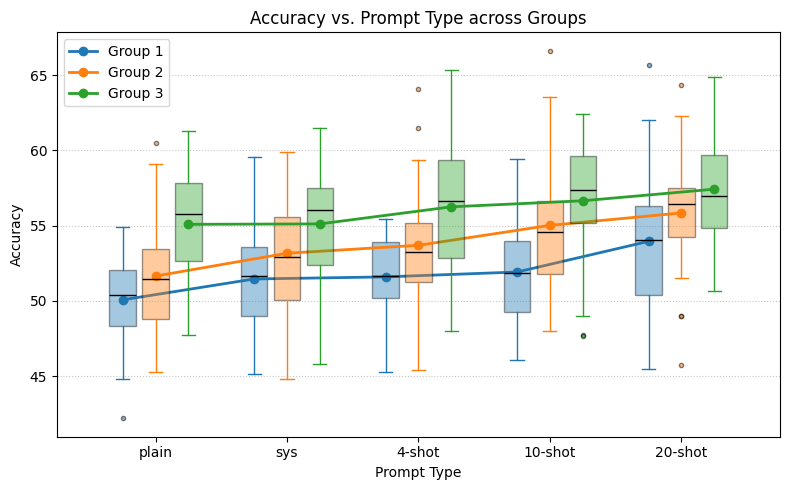

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data: 3 groups × 5 x-axis positions (each group can have different sample sizes)
rng = np.random.default_rng(42)
group_data = [
    [rng.normal(50 + i*2 + j, 4, 30) for j in range(5)]  # Group 1 (e.g., Model A)
    for i in range(3)
]

# Plot configuration
labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green
x = np.arange(len(labels))  # 0..4

fig, ax = plt.subplots(figsize=(8, 5))

width = 0.25  # spacing between box groups
offsets = [-width, 0, width]

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    # Shift x positions slightly for grouped boxes
    positions = x + offset
    
    # Boxplots
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color),
    )
    
    # Compute and connect means
    means = [np.mean(g) for g in group]
    ax.plot(positions, means, marker='o', color=color, label=f'Group {i+1}', linewidth=2)

# X-axis configuration
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. Prompt Type across Groups")

# Cosmetics
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

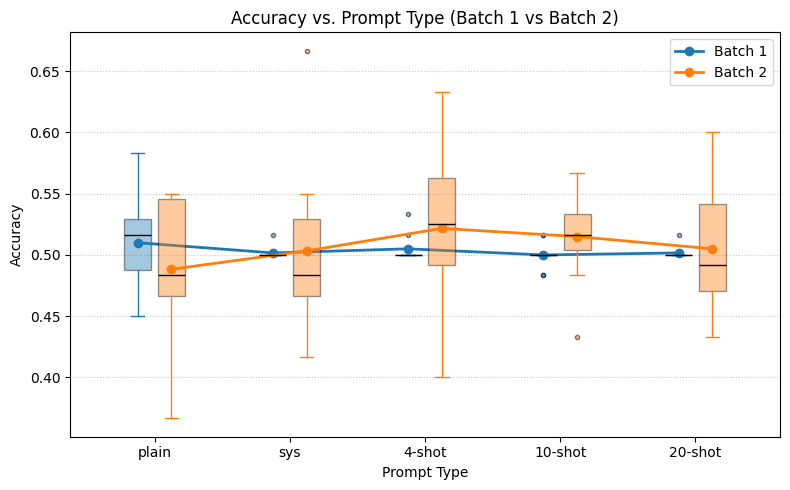

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load accuracy data ===
batch1 = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_qwen/accuracy_summary_batch1.csv", index_col="response_id")
batch2 = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_llama/accuracy_summary_batch2.csv", index_col="response_id")

prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]
batch1 = batch1[prompt_labels]
batch2 = batch2[prompt_labels]

# === Prepare group data (2 groups × 5 prompts) ===
group_data = []
for df in [batch1, batch2]:
    series_list = [df[col].dropna().values for col in prompt_labels]
    group_data.append(series_list)

# === Plot ===
x = np.arange(len(prompt_labels))  # 0..4
colors = ['#1f77b4', '#ff7f0e']  # blue (Batch1), orange (Batch2)
labels_group = ['Batch 1', 'Batch 2']
width = 0.25
offsets = [-width / 2, width / 2]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color),
    )
    means = [np.mean(g) for g in group]
    ax.plot(positions, means, marker='o', color=color, label=labels_group[i], linewidth=2)

# Axis labels & style
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. Prompt Type (Batch 1 vs Batch 2)")

ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


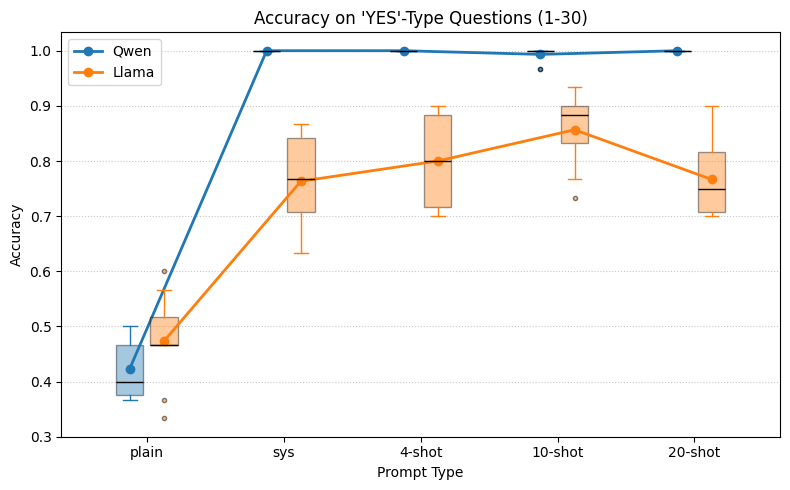

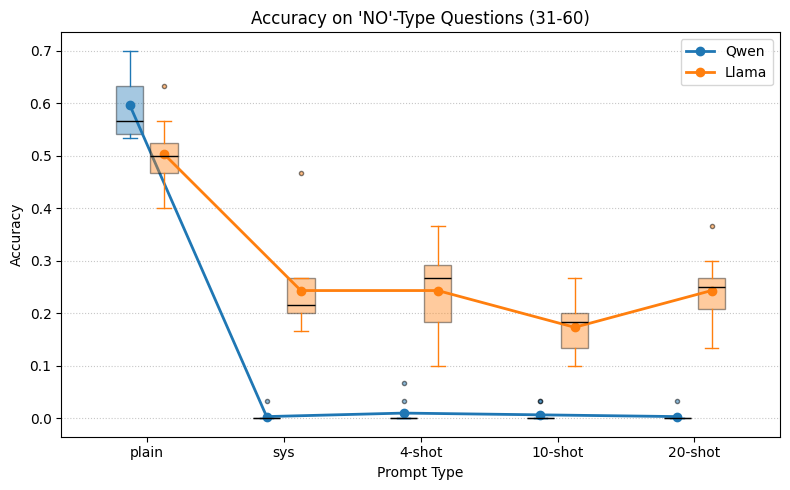

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load split accuracy data ===
batch1 = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_qwen/Split_Accuracy__Batch_1_.csv", index_col="response_id")
batch2 = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_llama/Split_Accuracy__Batch_2_.csv", index_col="response_id")

# === Prompt labels ===
prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]
colors = ['#1f77b4', '#ff7f0e']   # blue/orange
labels_group = ['Qwen', 'Llama']

# === Function to prepare and plot for yes/no ===
def plot_split(type_suffix, title):
    # Extract yes/no data from both batches
    group_data = []
    for df in [batch1, batch2]:
        cols = [f"{p}_{type_suffix}" for p in prompt_labels]
        series_list = [df[c].dropna().values for c in cols]
        group_data.append(series_list)
    
    # Plot
    x = np.arange(len(prompt_labels))
    width = 0.25
    offsets = [-width/2, width/2]
    
    fig, ax = plt.subplots(figsize=(8,5))
    for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
        positions = x + offset
        bp = ax.boxplot(
            group,
            positions=positions,
            widths=width*0.8,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.4),
            medianprops=dict(color='black'),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color),
        )
        means = [np.mean(g) for g in group]
        ax.plot(positions, means, marker='o', color=color, label=labels_group[i], linewidth=2)

    ax.set_xticks(x)
    ax.set_xticklabels(prompt_labels)
    ax.set_xlabel("Prompt Type")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# === Plot yes/no separately ===
plot_split("yes", "Accuracy on 'YES'-Type Questions (1-30)")
plot_split("no", "Accuracy on 'NO'-Type Questions (31-60)")


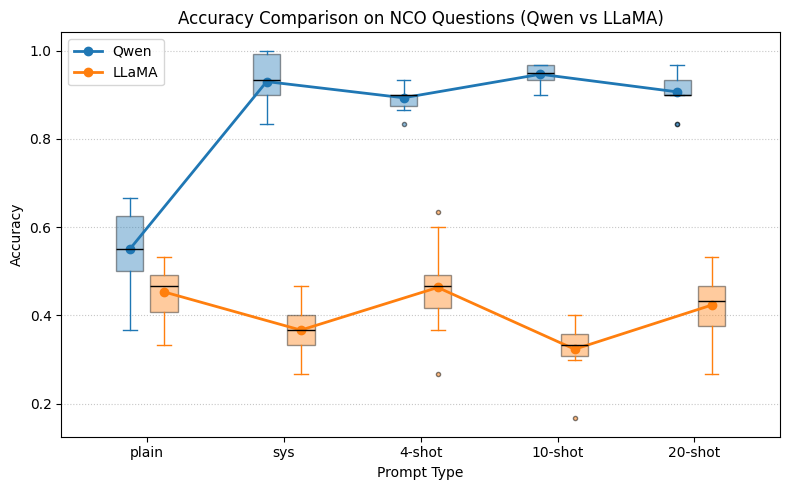

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load accuracy data for Qwen and LLaMA ===
qwen = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_qwen/qwen_q31_60_accuracy_summary.csv")
llama = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_llama/llama_q31_60_accuracy_summary.csv")

prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]
colors = ['#1f77b4', '#ff7f0e']   # blue (Qwen), orange (LLaMA)
labels_group = ['Qwen', 'LLaMA']

# === Prepare group data (2 groups × 5 prompts) ===
group_data = []
for df in [qwen, llama]:
    series_list = [df[col].dropna().values for col in prompt_labels]
    group_data.append(series_list)

# === Plot ===
x = np.arange(len(prompt_labels))  # 0..4
width = 0.25
offsets = [-width / 2, width / 2]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color),
    )
    means = [np.mean(g) for g in group]
    ax.plot(positions, means, marker='o', color=color, label=labels_group[i], linewidth=2)

# Axis labels & style
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on NCO Questions (Qwen vs LLaMA)")

ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


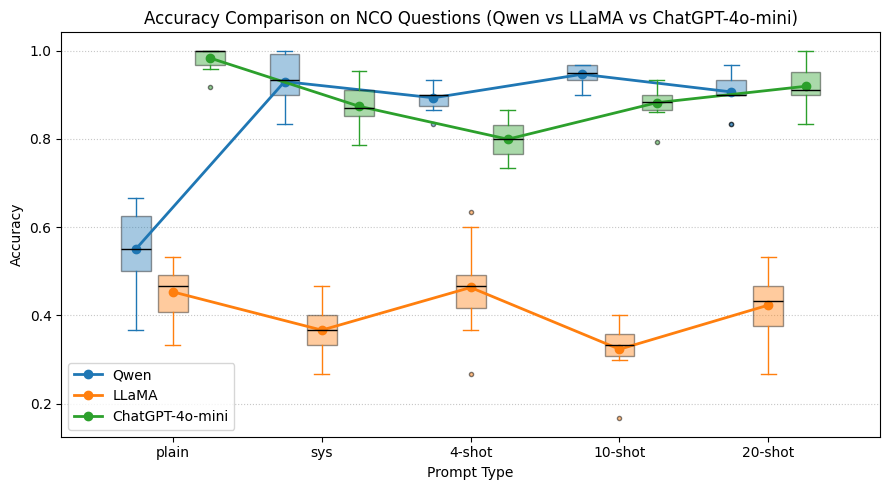

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load accuracy data for Qwen, LLaMA ===
qwen = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_qwen/qwen_q31_60_accuracy_summary.csv")
llama = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_llama/llama_q31_60_accuracy_summary.csv")

# === Embedded ChatGPT-4o-mini data ===
data = [
    [0.958333, 0.920000, 0.827586, 0.933333, 0.941176],
    [1.000000, 0.785714, 0.733333, 0.866667, 1.000000],
    [1.000000, 0.851852, 0.800000, 0.866667, 0.960000],
    [1.000000, 0.880000, 0.766667, 0.862069, 0.954545],
    [1.000000, 0.884615, 0.800000, 0.900000, 0.900000],
    [1.000000, 0.851852, 0.766667, 0.900000, 0.900000],
    [1.000000, 0.954545, 0.833333, 0.900000, 0.909091],
    [0.916667, 0.827586, 0.766667, 0.793103, 0.913043],
    [1.000000, 0.862069, 0.866667, 0.866667, 0.833333],
    [0.958333, 0.923077, 0.833333, 0.933333, 0.882353],
]
gpt4omini = pd.DataFrame(data, columns=["plain", "sys", "4-shot", "10-shot", "20-shot"])

# === Prompt & styling setup ===
prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # 蓝、橙、绿
labels_group = ['Qwen', 'LLaMA', 'ChatGPT-4o-mini']

# === Prepare group data (3 groups × 5 prompts) ===
group_data = []
for df in [qwen, llama, gpt4omini]:
    series_list = [df[col].dropna().values for col in prompt_labels]
    group_data.append(series_list)

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.25
offsets = [-width, 0, width]  # 三组箱线图位置偏移

fig, ax = plt.subplots(figsize=(9, 5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color),
    )
    means = [np.mean(g) for g in group]
    ax.plot(positions, means, marker='o', color=color, label=labels_group[i], linewidth=2)

# === Axis labels & style ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on NCO Questions (Qwen vs LLaMA vs ChatGPT-4o-mini)")

ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


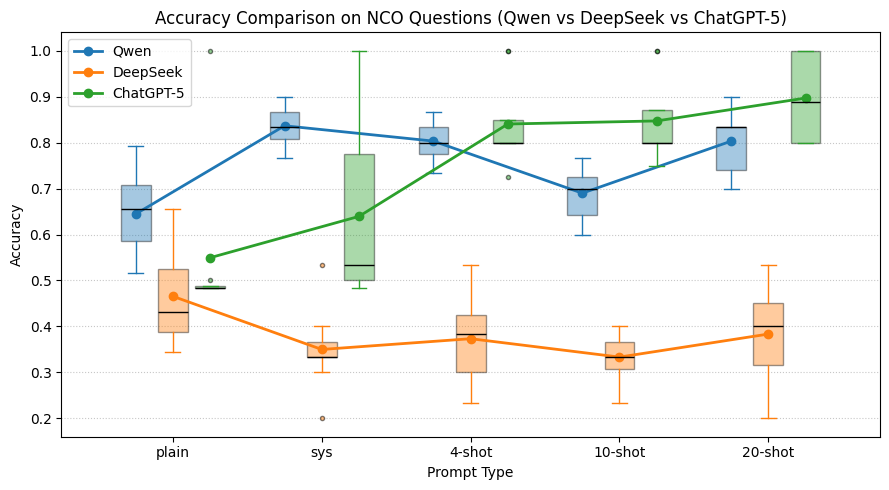

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load accuracy data for Qwen & DeepSeek ===
qwen = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_qwen/parsed_response_accuracy_summary.csv")
deepseek = pd.read_csv("~/nco-benchmark/ability-test/huggingface/results_deepseek/parsed_response_accuracy_summary_transposed.csv")


# === Load ChatGPT-5 data ===
gpt5 = pd.read_csv("chatgpt5_runwise_accuracy.csv")   # 改成你的实际路径
gpt5 = gpt5[["v1", "v2", "v3", "v4", "v5"]]           # 去掉 response_id
gpt5.columns = ["plain", "sys", "4-shot", "10-shot", "20-shot"]

# === Prompt & styling setup ===
prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # 蓝、橙、绿
labels_group = ['Qwen', 'DeepSeek', 'ChatGPT-5']

# === Prepare group data (3 groups × 5 prompts) ===
group_data = []
for df in [qwen, deepseek, gpt5]:
    series_list = [df[col].dropna().values for col in prompt_labels]
    group_data.append(series_list)

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=color),
    )
    means = [np.mean(g) for g in group]
    ax.plot(positions, means, marker='o', color=color, label=labels_group[i], linewidth=2)

# === Axis labels & style ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on NCO Questions (Qwen vs DeepSeek vs ChatGPT-5)")

ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


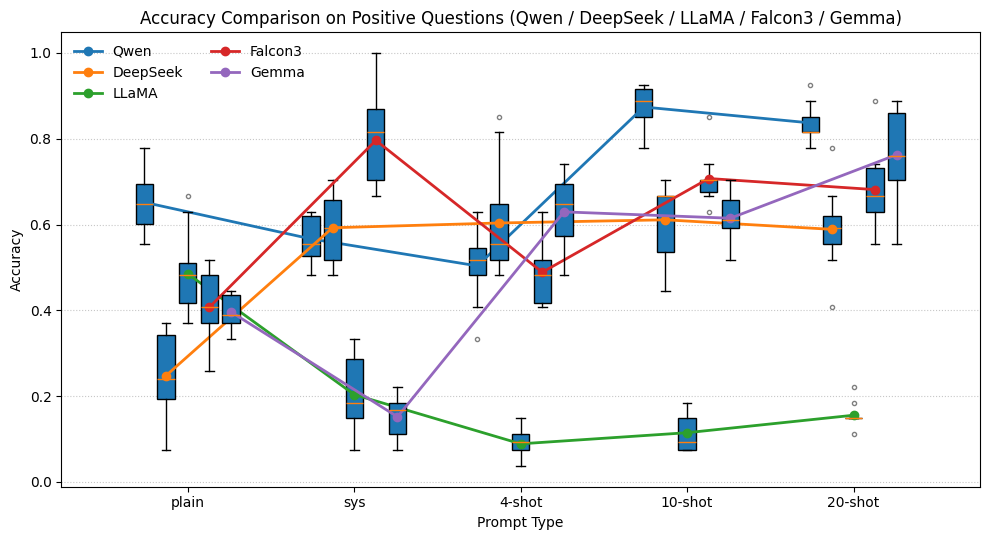

'huggingface/Accuracy/positive_accuracy_boxplot.png'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 positive-accuracy files we generated ===
base = Path("./huggingface/Accuracy")
files = {
    "Qwen": base / "positive_qwen_accuracy.csv",
    "DeepSeek": base / "positive_deepseek_accuracy.csv",
    "LLaMA": base / "positive_llama_accuracy.csv",
    "Falcon3": base / "positive_falcon3_accuracy.csv",
    "Gemma": base / "positive_gemma_accuracy.csv",
}

# Map versions to prompt labels
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "4-shot", "v4": "10-shot", "v5": "20-shot"}
prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]

# Helper to convert version-based runwise accuracies to list per prompt type
def df_to_series_list(df: pd.DataFrame, prompts):
    # Ensure columns exist
    if not {"version", "response_id", "accuracy"}.issubset(df.columns):
        raise ValueError("Input CSV must contain 'version', 'response_id', and 'accuracy' columns.")
    # Build a list of arrays ordered by prompts
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values  # should have 10 values (response_id 1..10)
        series_by_prompt.append(accs)
    return series_by_prompt

group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Plot (single matplotlib plot, no specific colors) ===
x = np.arange(len(prompt_labels))
width = 0.13
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, offset) in enumerate(zip(group_data, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,  # use defaults for colors/styles
        medianprops=dict(),
        whiskerprops=dict(),
        capprops=dict(),
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', linewidth=2, label=labels_group[i])

ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on Positive Questions (Qwen / DeepSeek / LLaMA / Falcon3 / Gemma)")
ax.legend(ncol=2, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# Save figure
out_path = Path("./huggingface/Accuracy/positive_accuracy_boxplot.png")
plt.savefig(out_path, dpi=200)
plt.show()

str(out_path)


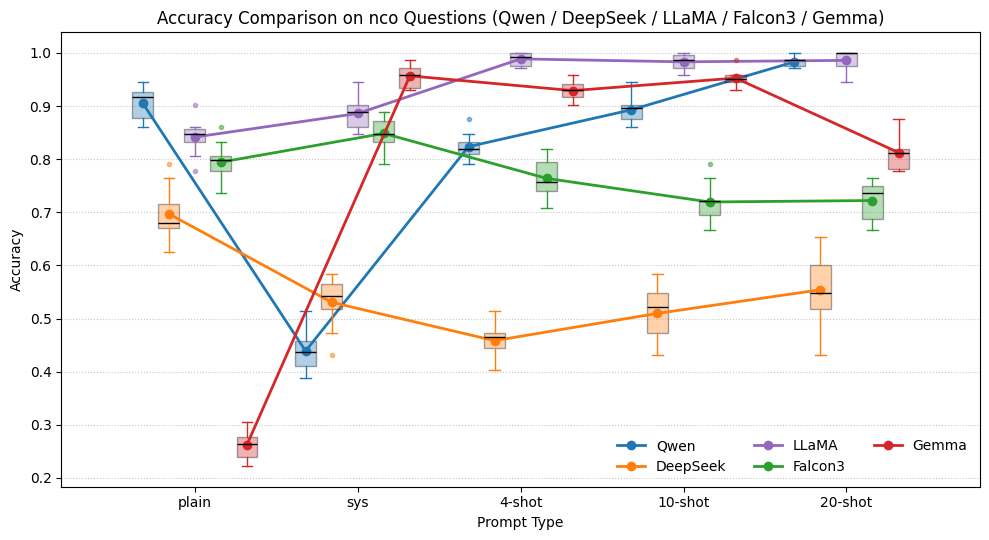

Saved figure to: huggingface/Accuracy/nco_accuracy_boxplot.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./huggingface/Accuracy")
files = {
    "Qwen": base / "nco_qwen_accuracy.csv",
    "DeepSeek": base / "nco_deepseek_accuracy.csv",
    "LLaMA": base / "nco_llama_accuracy.csv",
    "Falcon3": base / "nco_falcon3_7B_accuracy.csv",
    "Gemma": base / "nco_gemma_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "4-shot", "v4": "10-shot", "v5": "20-shot"}
prompt_labels = ["plain", "sys", "4-shot", "10-shot", "20-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728']  # 蓝橙紫绿红

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on nco Questions (Qwen / DeepSeek / LLaMA / Falcon3 / Gemma)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "nco_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


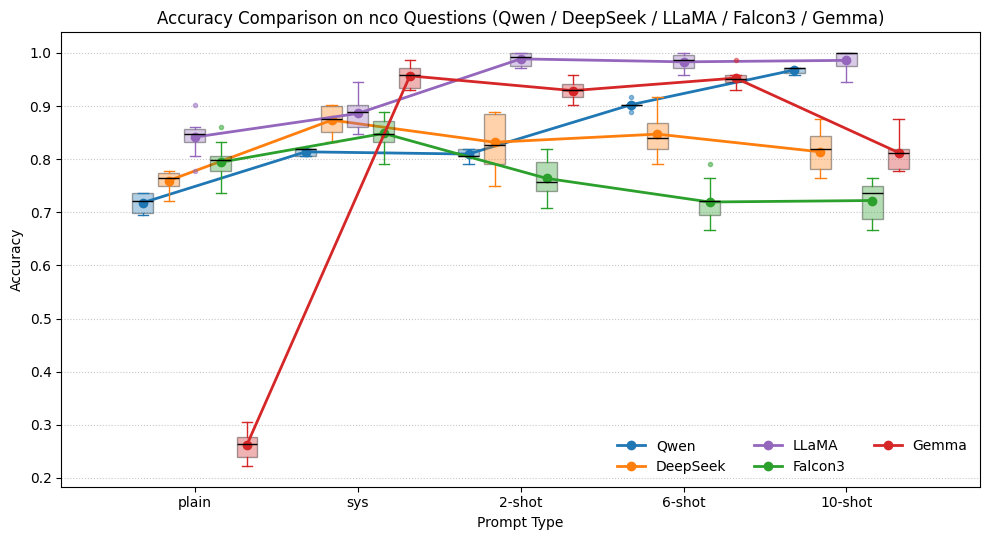

Saved figure to: huggingface/Accuracy/nco_accuracy_boxplot.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./huggingface/Accuracy")
files = {
    "Qwen": base / "nco_qwen_8B_accuracy.csv",
    "DeepSeek": base / "nco_deepseek_8B_accuracy.csv",
    "LLaMA": base / "nco_llama_accuracy.csv",
    "Falcon3": base / "nco_falcon3_7B_accuracy.csv",
    "Gemma": base / "nco_gemma_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728']  # 蓝橙紫绿红

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on nco Questions (Qwen / DeepSeek / LLaMA / Falcon3 / Gemma)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "nco_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


Saved F1 csv -> huggingface/Accuracy/f1_scores_by_run.csv


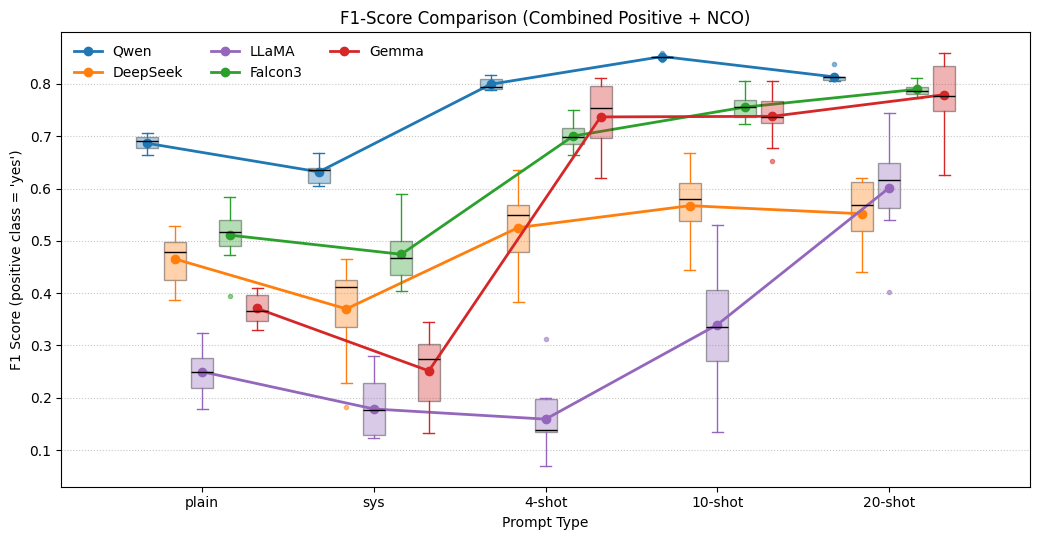

Saved F1 figure -> huggingface/Accuracy/f1_scores_boxplot.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === 根路径按你的项目结构 ===
ACC_DIR = Path("./huggingface/Accuracy")
NCO_RAW_ROOT = Path("./huggingface/NCO/NCO-results")
POS_RAW_ROOT = Path("./huggingface/Positive-results")

# === 已整理好的 accuracy CSV（在 Accuracy 文件夹） ===
acc_files_nco = {
    "Qwen":    ACC_DIR / "nco_qwen_8B_accuracy.csv",
    "DeepSeek":ACC_DIR / "nco_deepseek_8B_accuracy.csv",
    "LLaMA":   ACC_DIR / "nco_llama_accuracy.csv",
    "Falcon3": ACC_DIR / "nco_falcon3_7B_accuracy.csv",
    "Gemma":   ACC_DIR / "nco_gemma_accuracy.csv",
}
acc_files_pos = {
    "Qwen":    ACC_DIR / "positive_qwen_8B_accuracy.csv",
    "DeepSeek":ACC_DIR / "positive_deepseek_8B_accuracy.csv",
    "LLaMA":   ACC_DIR / "positive_llama_8B_accuracy.csv",
    "Falcon3": ACC_DIR / "positive_falcon3_7B_accuracy.csv",
    "Gemma":   ACC_DIR / "positive_gemma_accuracy.csv",
}

# === 原始结果目录（用于推断每版本题目数 N） ===
# 你截图里两处目录分别是：
#   ./huggingface/NCO/NCO-results/results_*
#   ./huggingface/Positive-results/results_*
RAW_DIRS_NCO = {
    "Qwen":    NCO_RAW_ROOT / "results_qwen",
    "DeepSeek":NCO_RAW_ROOT / "results_deepseek",
    "LLaMA":   NCO_RAW_ROOT / "results_llama",
    "Falcon3": NCO_RAW_ROOT / "results_falcon3",
    "Gemma":   NCO_RAW_ROOT / "results_gemma3",   # 你的项目里是 results_gemma3
}
RAW_PATTERN_NCO = "nco_v{v}_questions_multi10_*.csv"   # v1..v5

RAW_DIRS_POS = {
    "Qwen":    POS_RAW_ROOT / "results_qwen",
    "DeepSeek":POS_RAW_ROOT / "results_deepseek",
    "LLaMA":   POS_RAW_ROOT / "results_llama",
    "Falcon3": POS_RAW_ROOT / "results_falcon3",
    "Gemma":   POS_RAW_ROOT / "results_gemma3",   # positive gemma 在 results_gemma3
}
RAW_PATTERN_POS = "medical_questions_v{v}_*.csv"       # v1..v5

# === 版本到 prompt 标签 ===
VERSION_MAP = {"v1": "plain", "v2": "sys", "v3": "4-shot", "v4": "10-shot", "v5": "20-shot"}
PROMPTS = ["plain", "sys", "4-shot", "10-shot", "20-shot"]

# === 工具：安全读取 CSV，保证必要列存在 ===
def load_acc_csv(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing accuracy file: {path}")
    df = pd.read_csv(path)
    need = {"version", "response_id", "accuracy"}
    if not need.issubset(df.columns):
        raise KeyError(f"{path} must contain columns: {need}")
    return df

# === 工具：从原始结果里推断每版本题目数 N（失败则返回空 dict） ===
def infer_N_per_version(raw_dir: Path, pattern_fmt: str):
    Ns = {}
    if not raw_dir.exists():
        return Ns
    for v in range(1, 6):
        vs = f"v{v}"
        files = sorted(raw_dir.glob(pattern_fmt.format(v=v)))
        if not files:
            continue
        df = pd.read_csv(files[0])
        if "response_id" in df.columns:
            N_run = int((df["response_id"] == 1).sum())
            if N_run == 0:
                # 如果没法按 run 拆分，就用平均每个 run 的条数
                N_run = int(round(df.groupby("response_id").size().mean()))
        else:
            # 最笨的回退：总数 / 10
            N_run = int(round(len(df) / 10.0))
        Ns[vs] = N_run
    return Ns

# === 计算 F1（正类为“yes”） ===
def compute_f1(acc_nco_path: Path, acc_pos_path: Path, Ns_nco: dict, Ns_pos: dict, model_name: str):
    df_nco = load_acc_csv(acc_nco_path)
    df_pos = load_acc_csv(acc_pos_path)
    rows = []

    for vs, prompt in VERSION_MAP.items():
        # 取某版本的 10 次运行
        pos_run = df_pos[df_pos["version"] == vs][["response_id", "accuracy"]] \
                    .rename(columns={"accuracy": "acc_pos"})
        nco_run = df_nco[df_nco["version"] == vs][["response_id", "accuracy"]] \
                    .rename(columns={"accuracy": "acc_nco"})
        merged = pd.merge(pos_run, nco_run, on="response_id", how="inner")
        if merged.empty:
            continue

        # 尝试使用 N（若推断不到 N，则走概率式回退，不依赖 N）
        Np = Ns_pos.get(vs)
        Nn = Ns_nco.get(vs)

        for _, r in merged.iterrows():
            acc_pos = float(r["acc_pos"])
            acc_nco = float(r["acc_nco"])

            if Np is not None and Nn is not None:
                # 基于计数的精确计算
                TP = acc_pos * Np
                FN = Np - TP
                TN = acc_nco * Nn
                FP = Nn - TN
                denom_p = TP + FP
                precision = TP / denom_p if denom_p > 0 else np.nan
                recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
            else:
                # 概率式回退（不需要 N）：把 acc_pos 当作 P(y=1|pos)，把 (1-acc_nco) 当作 P(预测阳性|负样本)
                # 这样近似下：precision = acc_pos / (acc_pos + (1 - acc_nco))，recall = acc_pos
                precision = acc_pos / (acc_pos + (1.0 - acc_nco)) if (acc_pos + (1.0 - acc_nco)) > 0 else np.nan
                recall = acc_pos

            f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else np.nan

            rows.append({
                "model": model_name,
                "version": vs,
                "prompt": prompt,
                "response_id": int(r["response_id"]),
                "acc_pos": acc_pos,
                "acc_nco": acc_nco,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "used_counts": bool(Np is not None and Nn is not None),
                "N_pos": int(Np) if Np is not None else None,
                "N_nco": int(Nn) if Nn is not None else None,
            })

    return pd.DataFrame(rows)

# === 构建 N 映射 ===
Ns_pos_map = {m: infer_N_per_version(RAW_DIRS_POS[m], RAW_PATTERN_POS) for m in RAW_DIRS_POS}
Ns_nco_map = {m: infer_N_per_version(RAW_DIRS_NCO[m], RAW_PATTERN_NCO) for m in RAW_DIRS_NCO}

# === 汇总所有模型的 F1 ===
models = ["Qwen", "DeepSeek", "LLaMA", "Falcon3", "Gemma"]
all_rows = []
for m in models:
    df_m = compute_f1(
        acc_files_nco[m], acc_files_pos[m],
        Ns_nco_map.get(m, {}), Ns_pos_map.get(m, {}),
        m
    )
    all_rows.append(df_m)

f1_df = pd.concat(all_rows, ignore_index=True)
out_csv = ACC_DIR / "f1_scores_by_run.csv"
f1_df.to_csv(out_csv, index=False)
print(f"Saved F1 csv -> {out_csv}")

# === 画图（配色与之前一致） ===
def df_to_series_by_prompt(df: pd.DataFrame, model: str):
    return [df[(df["model"] == model) & (df["prompt"] == p)]["f1"].dropna().values for p in PROMPTS]

colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728']  # Qwen, DeepSeek, LLaMA, Falcon3, Gemma
x = np.arange(len(PROMPTS))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(models))

fig, ax = plt.subplots(figsize=(10.5, 5.5))
for i, (m, color, offset) in enumerate(zip(models, colors, offsets)):
    data = df_to_series_by_prompt(f1_df, m)
    pos = x + offset
    bp = ax.boxplot(
        data, positions=pos, widths=width * 0.8, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.nanmean(d) if len(d) else np.nan for d in data]
    ax.plot(pos, means, marker='o', color=color, linewidth=2, label=m)

ax.set_xticks(x)
ax.set_xticklabels(PROMPTS)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("F1 Score (positive class = 'yes')")
ax.set_title("F1-Score Comparison (Combined Positive + NCO)")
ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

out_fig = ACC_DIR / "f1_scores_boxplot.png"
plt.savefig(out_fig, dpi=200)
plt.show()
print(f"Saved F1 figure -> {out_fig}")


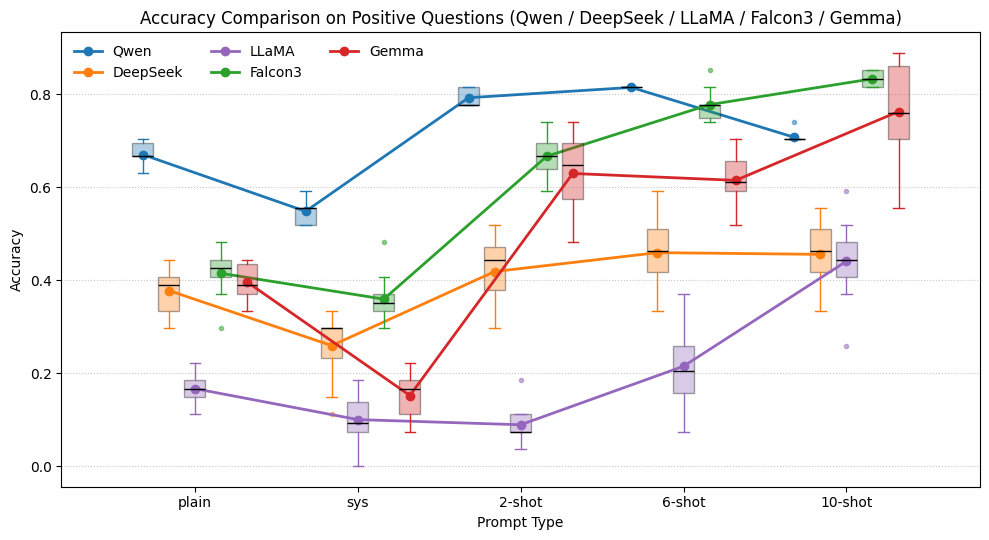

Saved figure to: huggingface/Accuracy/positive_accuracy_boxplot.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./huggingface/Accuracy")
files = {
    "Qwen": base / "positive_qwen_8B_accuracy.csv",
    "DeepSeek": base / "positive_deepseek_8B_accuracy.csv",
    "LLaMA": base / "positive_llama_8B_accuracy.csv",
    "Falcon3": base / "positive_falcon3_7B_accuracy.csv",
    "Gemma": base / "positive_gemma_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728']  # 蓝橙紫绿红

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on Positive Questions (Qwen / DeepSeek / LLaMA / Falcon3 / Gemma)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "positive_accuracy_boxplot.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


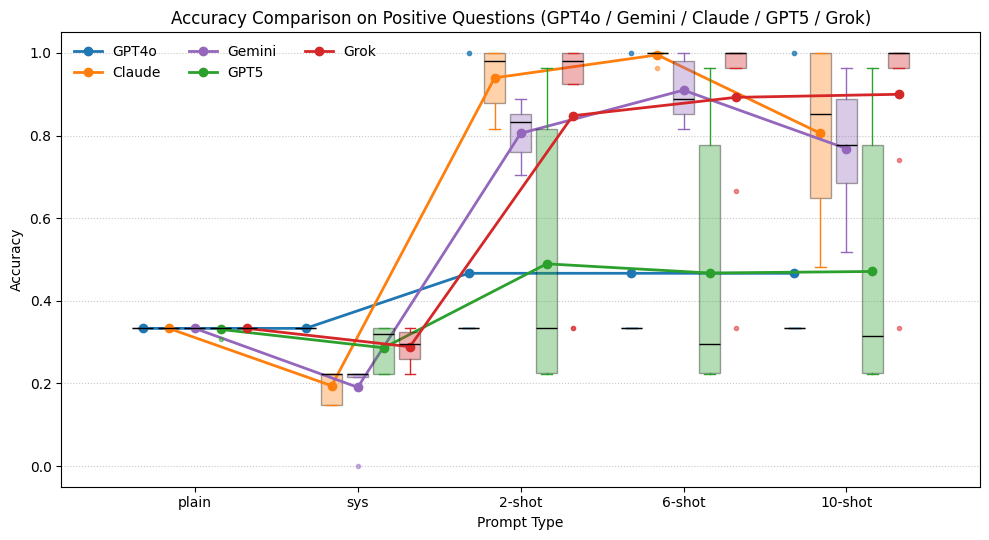

Saved figure to: huggingface/Accuracy/positive_accuracy_boxplot_api.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./huggingface/Accuracy")
files = {
    "GPT4o": base / "positive_gpt4o_accuracy.csv",
    "Claude": base / "positive_claude_accuracy.csv",
    "Gemini": base / "positive_gemini_accuracy.csv",
    "GPT5": base / "positive_gpt5_accuracy.csv",
    "Grok": base / "positive_grok_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728']  # 蓝橙紫绿红

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on Positive Questions (GPT4o / Gemini / Claude / GPT5 / Grok)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "positive_accuracy_boxplot_api.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")


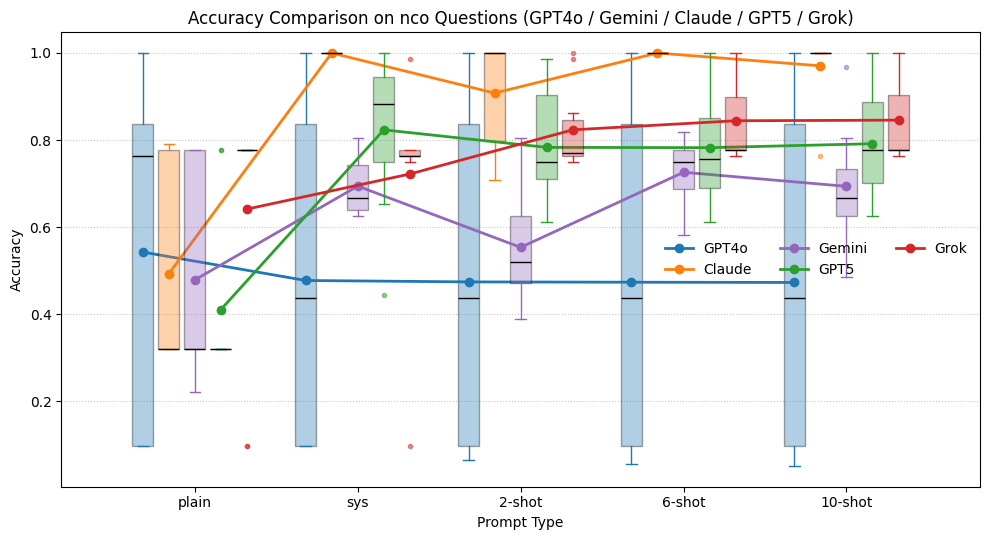

Saved figure to: huggingface/Accuracy/nco_accuracy_boxplot_api.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === Load the 5 nco-accuracy files ===
base = Path("./huggingface/Accuracy")
files = {
    "GPT4o": base / "nco_gpt4o_accuracy.csv",
    "Claude": base / "nco_claude_accuracy.csv",
    "Gemini": base / "nco_gemini_accuracy.csv",
    "GPT5": base / "nco_gpt5_accuracy.csv",
    "Grok": base / "nco_grok_accuracy.csv",
}

# === Prompt label mapping ===
version_to_prompt = {"v1": "plain", "v2": "sys", "v3": "2-shot", "v4": "6-shot", "v5": "10-shot"}
prompt_labels = ["plain", "sys", "2-shot", "6-shot", "10-shot"]

def df_to_series_list(df: pd.DataFrame, prompts):
    """Convert version-based runwise accuracies to list per prompt type."""
    series_by_prompt = []
    for p in prompts:
        v = [k for k, val in version_to_prompt.items() if val == p][0]
        accs = df[df["version"] == v]["accuracy"].dropna().values
        series_by_prompt.append(accs)
    return series_by_prompt

# === Prepare data ===
group_data = []
labels_group = list(files.keys())

for model in labels_group:
    df = pd.read_csv(files[model])
    group_data.append(df_to_series_list(df, prompt_labels))

# === Color palette ===
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728']  # 蓝橙紫绿红

# === Plot ===
x = np.arange(len(prompt_labels))
width = 0.16
offsets = np.linspace(-2*width, 2*width, len(labels_group))

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (group, color, offset) in enumerate(zip(group_data, colors, offsets)):
    positions = x + offset
    bp = ax.boxplot(
        group,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', markersize=3, alpha=0.5,
                        markerfacecolor=color, markeredgecolor=color),
    )
    means = [np.mean(g) if len(g) else np.nan for g in group]
    ax.plot(positions, means, marker='o', color=color,
            label=labels_group[i], linewidth=2)

# === Axis labels & styling ===
ax.set_xticks(x)
ax.set_xticklabels(prompt_labels)
ax.set_xlabel("Prompt Type")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison on nco Questions (GPT4o / Gemini / Claude / GPT5 / Grok)")

ax.legend(ncol=3, frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# === Save ===
out_path = base / "nco_accuracy_boxplot_api.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved figure to: {out_path}")
